# Proyek Klasifikasi Gambar: flower_photos
- **Nama:** Aqil Afif
- **Email:** aqfasmanju7@gmail.com
- **ID Dicoding:** aqil_afif_1c4h

## Import Semua Packages/Library yang Digunakan

In [9]:
# Install library yang diperlukan (jika menggunakan Google Colab)
!pip install split-folders
!pip install tensorflowjs

# Import library
import tensorflow as tf
import zipfile
import os
import shutil
import splitfolders
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from google.colab import files

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


## Data Preparation

### Data Loading

In [10]:
# Download dataset Flowers (contoh dataset yang valid >1000 gambar)
!wget --no-check-certificate \
  https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz \
  -O /tmp/flower_photos.tgz

# Ekstrak dataset
local_zip = '/tmp/flower_photos.tgz'
import tarfile
with tarfile.open(local_zip, 'r') as tar_ref:
    tar_ref.extractall('/tmp')

# Tentukan direktori dasar
base_dir = '/tmp/flower_photos'
print("Isi folder dataset:", os.listdir(base_dir))

# Menghapus file LICENSE.txt agar tidak terbaca sebagai label kelas
if os.path.exists(os.path.join(base_dir, 'LICENSE.txt')):
    os.remove(os.path.join(base_dir, 'LICENSE.txt'))

--2026-02-19 03:50:09--  https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
Resolving storage.googleapis.com (storage.googleapis.com)... 172.253.118.207, 74.125.200.207, 74.125.130.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.253.118.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228813984 (218M) [application/x-compressed-tar]
Saving to: ‘/tmp/flower_photos.tgz’

/tmp/flower_photos. 100%[===================>] 218.21M  22.6MB/s    in 11s     

2026-02-19 03:50:21 (20.0 MB/s) - ‘/tmp/flower_photos.tgz’ saved [228813984/228813984]



/tmp/ipython-input-560481079.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar_ref.extractall('/tmp')


Isi folder dataset: ['roses', 'daisy', 'dandelion', 'sunflowers', 'LICENSE.txt', 'tulips']


### Data Preprocessing

#### Split Dataset

In [11]:
# Bagi dataset: 80% Train, 10% Val, 10% Test
# 'seed' memastikan pembagian konsisten
splitfolders.ratio(base_dir, output="/tmp/flowers_split", seed=1337, ratio=(.8, .1, .1), group_prefix=None, move=False)

train_dir = '/tmp/flowers_split/train'
val_dir = '/tmp/flowers_split/val'
test_dir = '/tmp/flowers_split/test'

# Augmentasi Gambar untuk Data Training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    shear_range=0.2,
    zoom_range=0.2,
    fill_mode='nearest'
)

# Rescale saja untuk Data Validation dan Test (Tidak boleh di-augmentasi)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load data ke dalam generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

Copying files: 3670 files [00:01, 3053.92 files/s]


Found 2934 images belonging to 5 classes.
Found 364 images belonging to 5 classes.
Found 372 images belonging to 5 classes.


## Modelling

In [12]:
# --- STEP 1: TRANSFER LEARNING (FROZEN BASE) ---
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input

# Load MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=Input(shape=(150, 150, 3)))
base_model.trainable = False # Bekukan base model dulu

model = tf.keras.models.Sequential([
    base_model,
    # Conv2D dengan padding='same' dan filter besar agar info tidak hilang
    tf.keras.layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(5, activation='softmax')
])

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

# Callback target 96%
class MyCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('accuracy') > 0.96 and logs.get('val_accuracy') > 0.96):
      print("\nAkurasi >96%! Training berhenti.")
      self.model.stop_training = True

callbacks = MyCallback()

print("\n--- Training Tahap 1 (Base Frozen) ---")
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=10,
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    verbose=2
)

# --- STEP 2: FINE TUNING (UNFREEZE) ---
print("\n--- Training Tahap 2 (Fine Tuning) ---")

# Unfreeze layer terakhir MobileNet
base_model.trainable = True
print(f"Jumlah layer di base model: {len(base_model.layers)}")

# Bekukan semua layer KECUALI 30 layer terakhir
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

# Compile ulang dengan Learning Rate SANGAT KECIL (penting!)
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(1e-5), # 1e-5 sangat lambat tapi presisi
              metrics=['accuracy'])

# Lanjut training
history_fine = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=30, # Tambah epoch untuk fine tuning
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    verbose=2,
    callbacks=[callbacks]
)

# Gabungkan history untuk plotting nanti
history_acc = history.history['accuracy'] + history_fine.history['accuracy']
history_val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
history_loss = history.history['loss'] + history_fine.history['loss']
history_val_loss = history.history['val_loss'] + history_fine.history['val_loss']

/tmp/ipython-input-3991064581.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=Input(shape=(150, 150, 3)))


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 5, 5, 256)      │     2,949,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,274,437 (20.12 MB)

 Trainable params: 3,016,453 (11.51 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


--- Training Tahap 1 (Base Frozen) ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
92/92 - 52s - 566ms/step - accuracy: 0.6653 - loss: 1.4041 - val_accuracy: 0.8352 - val_loss: 0.4683
Epoch 2/10
92/92 - 60s - 650ms/step - accuracy: 0.8020 - loss: 0.5527 - val_accuracy: 0.8434 - val_loss: 0.4283
Epoch 3/10
92/92 - 21s - 231ms/step - accuracy: 0.8344 - loss: 0.4644 - val_accuracy: 0.8379 - val_loss: 0.3990
Epoch 4/10
92/92 - 41s - 448ms/step - accuracy: 0.8609 - loss: 0.3910 - val_accuracy: 0.8516 - val_loss: 0.3646
Epoch 5/10
92/92 - 22s - 237ms/step - accuracy: 0.8661 - loss: 0.3748 - val_accuracy: 0.8571 - val_loss: 0.3731
Epoch 6/10
92/92 - 21s - 231ms/step - accuracy: 0.8845 - loss: 0.3186 - val_accuracy: 0.8681 - val_loss: 0.3484
Epoch 7/10
92/92 - 21s - 225ms/step - accuracy: 0.9015 - loss: 0.2732 - val_accuracy: 0.8929 - val_loss: 0.3297
Epoch 8/10
92/92 - 21s - 232ms/step - accuracy: 0.9097 - loss: 0.2431 - val_accuracy: 0.8544 - val_loss: 0.3821
Epoch 9/10
92/92 - 21s - 232ms/step - accuracy: 0.9151 - loss: 0.2303 - val_accuracy: 0.8736 - val_loss:

## Evaluasi dan Visualisasi

12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 782ms/step - accuracy: 0.8985 - loss: 0.3634

Akurasi pada Data Test: 89.25%


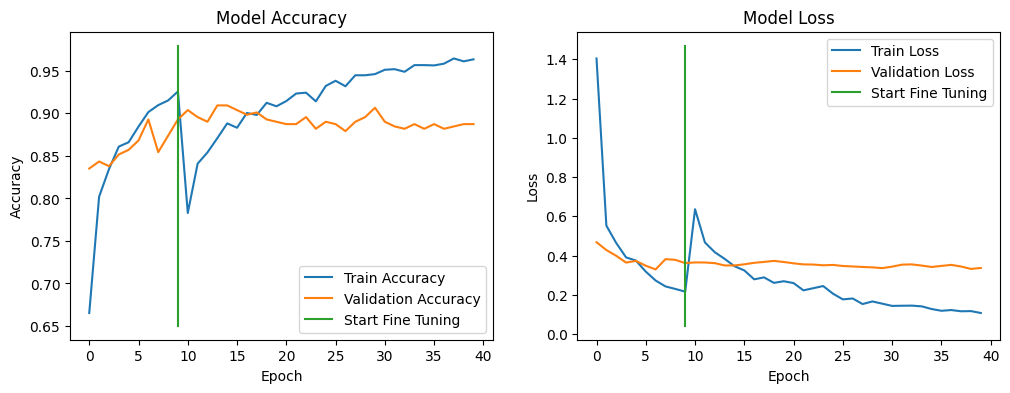

In [13]:
# Evaluasi pada data Test
eval_loss, eval_acc = model.evaluate(test_generator)
print(f"\nAkurasi pada Data Test: {eval_acc*100:.2f}%")

# Plot Akurasi (Gabungan)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_acc, label='Train Accuracy')
plt.plot(history_val_acc, label='Validation Accuracy')
plt.plot([9, 9], plt.ylim(), label='Start Fine Tuning') # Garis batas fine tuning
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')

# Plot Loss (Gabungan)
plt.subplot(1, 2, 2)
plt.plot(history_loss, label='Train Loss')
plt.plot(history_val_loss, label='Validation Loss')
plt.plot([9, 9], plt.ylim(), label='Start Fine Tuning')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.show()

## Konversi Model

In [14]:
# 1. Simpan model .h5 (untuk TFJS) dan SavedModel (untuk TFLite)
export_dir = 'saved_model/'

# Menggunakan try-except untuk kompatibilitas Keras 3 (Colab terbaru) dan Keras 2
try:
    # Keras 3: Gunakan model.export() untuk SavedModel
    model.export(export_dir)
except AttributeError:
    # Keras 2: Gunakan tf.saved_model.save()
    tf.saved_model.save(model, export_dir)

# Simpan dalam format H5 untuk TFJS (input_format=keras membutuhkan .h5 atau .keras)
model.save('model.h5')

# 2. Konversi ke TF-Lite
converter = tf.lite.TFLiteConverter.from_saved_model(export_dir)
tflite_model = converter.convert()

with open('model.tflite', 'wb') as f:
  f.write(tflite_model)

# 3. Konversi ke TFJS
# Membuat folder output
!mkdir tfjs_model
# Perintah konversi (gunakan input model.h5 agar stabil)
!tensorflowjs_converter \
    --input_format=keras \
    --output_format=tfjs_layers_model \
    model.h5 \
    tfjs_model/

print("Konversi selesai! Cek tab 'Files' di sebelah kiri untuk mengunduh model.")

Saved artifact at 'saved_model/'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor_316')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  139142052679504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139142052681232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139142052681040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139142052680272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139142052681808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139142052680080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139142052681424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139142052681616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139142052680656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139142052682768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13914205268219

mkdir: cannot create directory ‘tfjs_model’: File exists
2026-02-19 04:08:27.611882: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771474107.634322    9171 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771474107.641088    9171 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771474107.658771    9171 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771474107.658793    9171 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771474107.658796 

## Inference (Optional)

Saving 563847503_89e9756c80.jpg to 563847503_89e9756c80.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
563847503_89e9756c80.jpg
Gambar diprediksi sebagai: roses


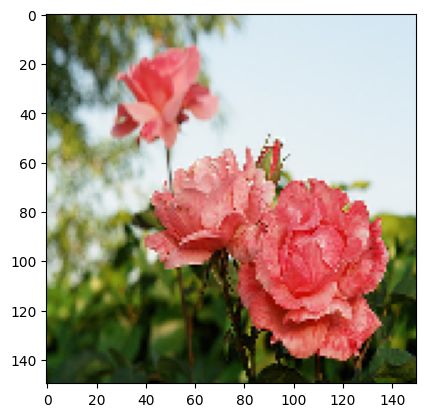

In [15]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image

uploaded = files.upload()

for fn in uploaded.keys():
  # Prediksi gambar
  path = fn
  img = image.load_img(path, target_size=(150, 150))

  imgplot = plt.imshow(img)
  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0)
  x = tf.keras.applications.mobilenet_v2.preprocess_input(x) # Preprocess penting utk MobileNet
  images = np.vstack([x])

  classes = model.predict(images, batch_size=10)
  print(fn)

  # Mendapatkan label kelas (sesuaikan urutan folder generator)
  # Biasanya urutan alfabetis: daisy, dandelion, roses, sunflowers, tulips
  class_names = sorted(os.listdir(train_dir))
  predicted_index = np.argmax(classes)
  predicted_class = class_names[predicted_index]

  print(f"Gambar diprediksi sebagai: {predicted_class}")